# Esercitazione 4

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def boltzman_distribution(v,T):
    return np.sqrt(2.0 / np.pi) * (1.0 / T)**1.5 * (v**2) * np.exp(- (v**2) / (2.0 * T))

# Esercizio 4.2
Grafico della distribuzione delle velocità partendo da una configurazione a entropia molto bassa

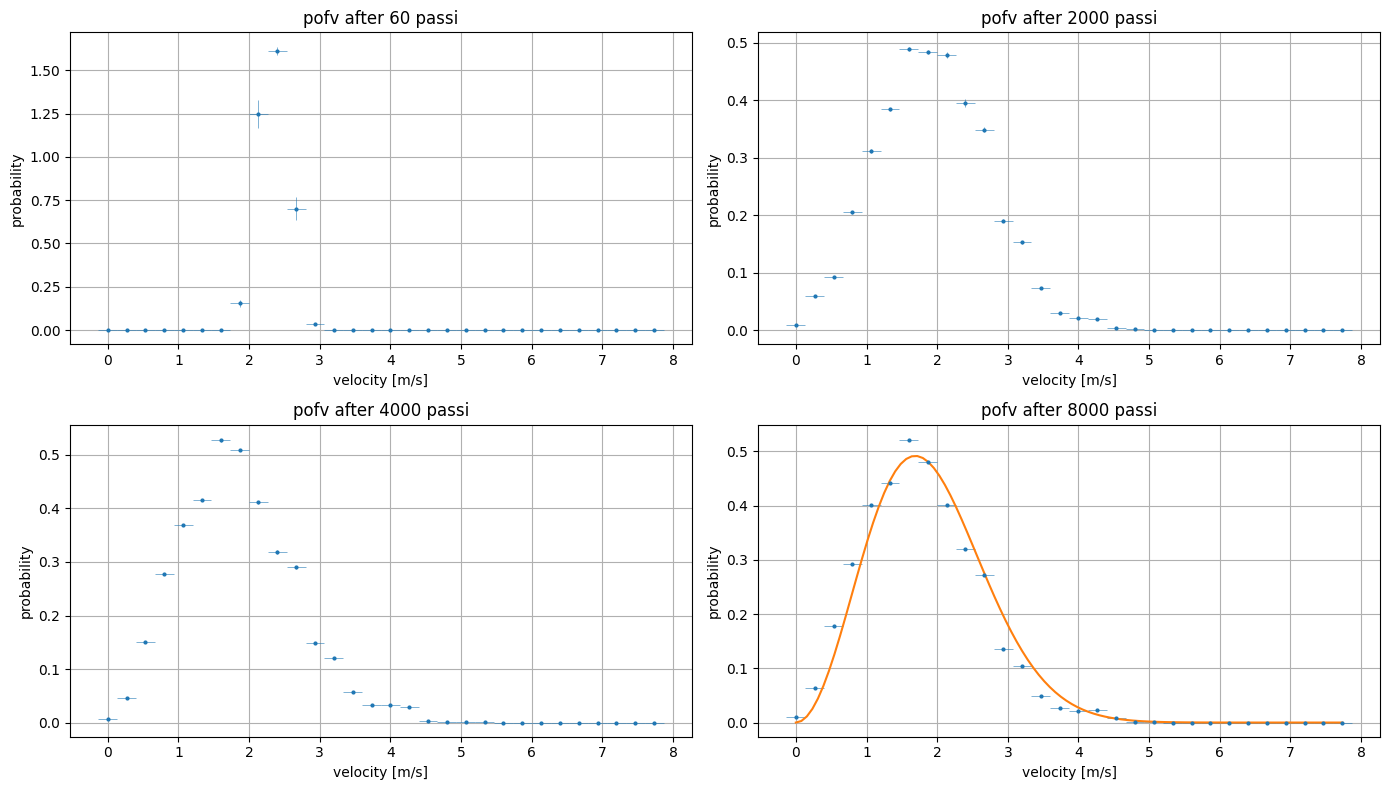

In [3]:
v, average, errors = np.loadtxt('../OUTPUT/pofv1.dat', unpack=True)

fig, axx = plt.subplots(2, 2 ,figsize=(14, 8)) 
axx = axx.flatten()
dim = 30
dv= (v[1]-v[0])*0.5
tem=np.loadtxt('../OUTPUT/temperature1.dat', usecols= 2)

passi= [60,2000,4000,8000]
for i,ax in enumerate(axx):

    ax.errorbar(v[i*dim: (i+1)*dim], average[i*dim: (i+1)*dim], xerr= dv,  yerr=errors[i*dim: (i+1)*dim], fmt='o', markersize=2, elinewidth=0.4)
    ax.set_xlabel('velocity [m/s]')
    ax.set_ylabel('probability')
    ax.set_title(f"pofv after {passi[i]} passi")
    ax.grid(True)

x= np.linspace(0., v[-1], 100)

temp = tem[-1]

v_t = boltzman_distribution(x, temp)

axx[3].plot(x, v_t)


plt.tight_layout()
plt.show()



Vediamo che la distribuzione delle velocità, partita da una delta di Dirac, si è evoluta fino a tendere alla curva teorica di Boltzmann

# Esercizio 4.3
Inversione temporale

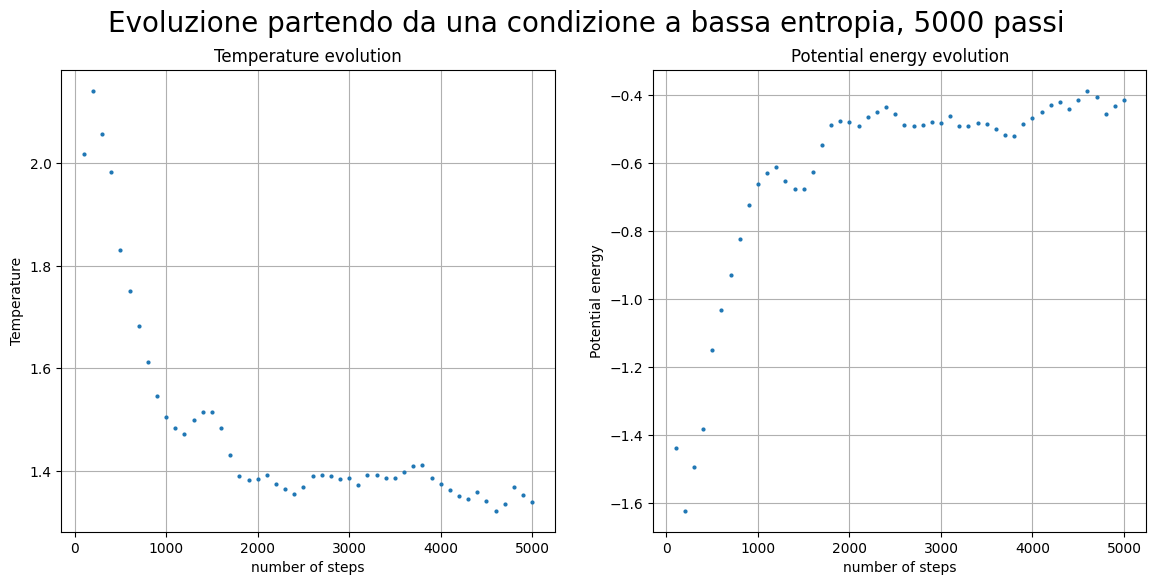

In [5]:
i, tem= np.loadtxt("../OUTPUT/temperature3.dat", unpack=True, usecols=(0,1))
j, penergy =  np.loadtxt("../OUTPUT/potential_energy3.dat", unpack=True, usecols=(0,1))
# plt.errorbar(tem[0, :], tem[1, :], tem[2, :], fmt='o')
i*=100
j*=100
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize= (14, 6))

fig.suptitle("Evoluzione partendo da una condizione a bassa entropia, 5000 passi", fontsize =20)
ax1.errorbar(i, tem, fmt='o', markersize= 2)
ax1.set_xlabel("number of steps")
ax1.set_ylabel("Temperature")
ax1.set_title("Temperature evolution")
ax1.grid(True)

ax2.errorbar(j, penergy, fmt='o', markersize= 2)
ax2.set_xlabel("number of steps")
ax2.set_ylabel("Potential energy")
ax2.set_title("Potential energy evolution")
ax2.grid(True)




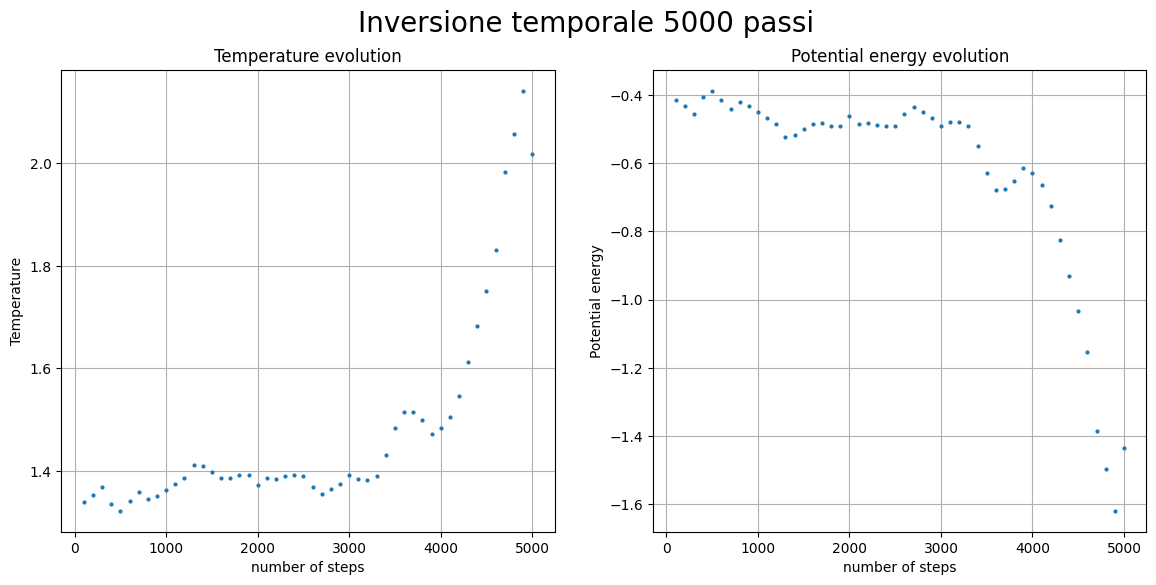

In [6]:
i, tem= np.loadtxt("../OUTPUT/temperature2.dat", unpack=True, usecols=(0,1))
j, penergy=  np.loadtxt("../OUTPUT/potential_energy2.dat", unpack=True, usecols=(0,1))
# plt.errorbar(tem[0, :], tem[1, :], tem[2, :], fmt='o')
i*=100
j*=100
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize= (14, 6))
fig.suptitle("Inversione temporale 5000 passi", fontsize=20)

ax1.errorbar(i, tem, fmt='o', markersize= 2)
ax1.set_xlabel("number of steps")
ax1.set_ylabel("Temperature")
ax1.set_title("Temperature evolution")
ax1.grid(True)

ax2.errorbar(j, penergy, fmt='o', markersize= 2)
ax2.set_xlabel("number of steps")
ax2.set_ylabel("Potential energy")
ax2.set_title("Potential energy evolution")
ax2.grid(True)



Vediamo che in questo caso l'inversione temporale ci riporta effettivamente nella condizione iniziale a bassa entropia dimostrando che l'algoritmo è reversibile almeno per un numero di passi minore o uguale a 5000.

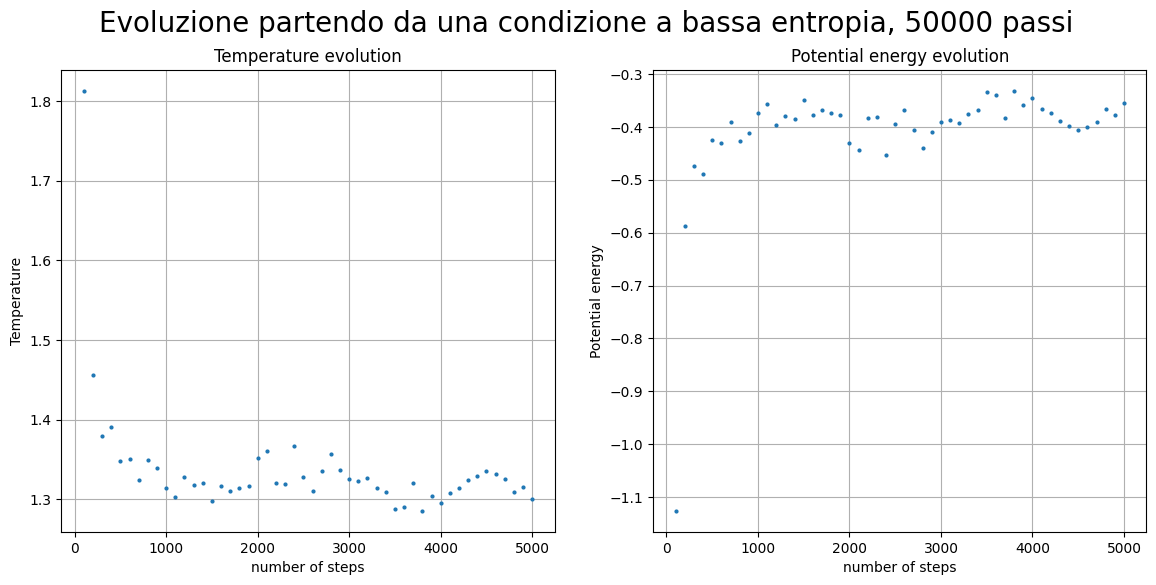

In [7]:
i, tem= np.loadtxt("../OUTPUT/temperature4.dat", unpack=True, usecols=(0,1))
j, penergy=  np.loadtxt("../OUTPUT/potential_energy4.dat", unpack=True, usecols=(0,1))
# plt.errorbar(tem[0, :], tem[1, :], tem[2, :], fmt='o')
i*=100
j*=100
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize= (14, 6))

fig.suptitle("Evoluzione partendo da una condizione a bassa entropia, 50000 passi", fontsize =20)

ax1.errorbar(i, tem, fmt='o', markersize= 2)
ax1.set_xlabel("number of steps")
ax1.set_ylabel("Temperature")
ax1.set_title("Temperature evolution")
ax1.grid(True)

ax2.errorbar(j, penergy, fmt='o', markersize= 2)
ax2.set_xlabel("number of steps")
ax2.set_ylabel("Potential energy")
ax2.set_title("Potential energy evolution")
ax2.grid(True)

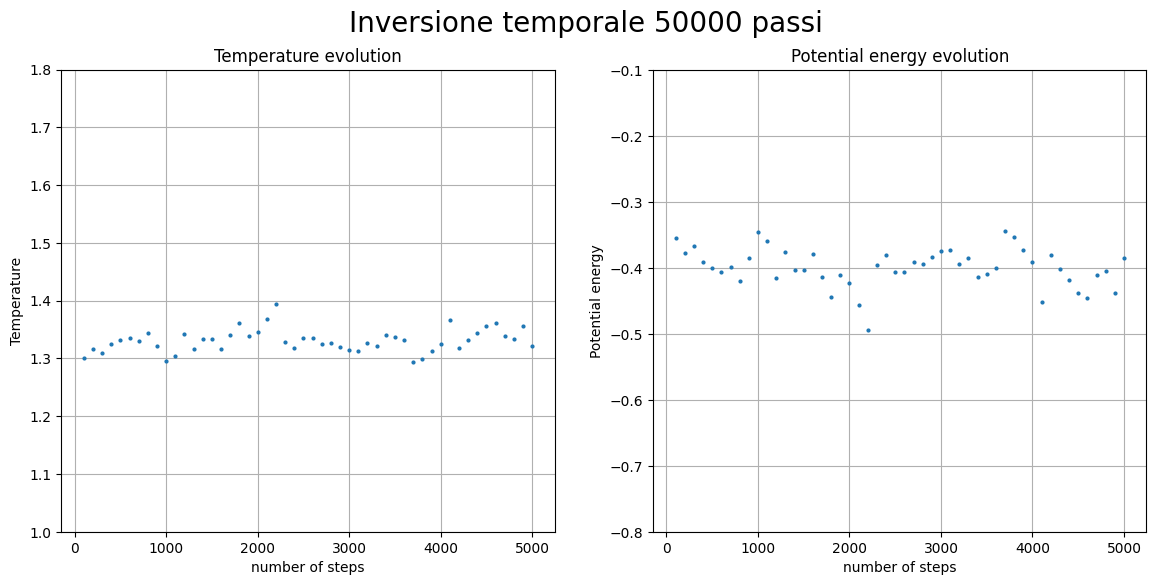

In [8]:
i, tem= np.loadtxt("../OUTPUT/temperature5.dat", unpack=True, usecols=(0,1))
j, penergy =  np.loadtxt("../OUTPUT/potential_energy5.dat", unpack=True, usecols=(0,1))
# plt.errorbar(tem[0, :], tem[1, :], tem[2, :], fmt='o')
i*=100
j*=100
fig, (ax1, ax2)  = plt.subplots(1, 2, figsize= (14, 6))

fig.suptitle("Inversione temporale 50000 passi", fontsize=20)
ax1.errorbar(i, tem, fmt='o', markersize= 2)
ax1.set_xlabel("number of steps")
ax1.set_ylabel("Temperature")
ax1.set_title("Temperature evolution")
ax1.set_ylim(1., 1.8)
ax1.grid(True)

ax2.errorbar(j, penergy, fmt='o', markersize= 2)
ax2.set_xlabel("number of steps")
ax2.set_ylabel("Potential energy")
ax2.set_title("Potential energy evolution")
ax2.set_ylim(-0.8, -0.1)
ax2.grid(True)

In questo caso invece non torniamo nella configurazione iniziale come ci saremmo aspettati. Questo succede a causa degli errori di arrotondamento, i quali, dopo molti passi, compromettono la capacità dell'algoritmo di tornare indietro. il sistema si è evoluto rimanendo vicino alla condizione di equilibrio perché sono le condizioni più probabili